# Do the *boring* bonds quietly win? 🐢
### The low-risk anomaly (betting-against-beta) — real in stocks, invisible on a basket of bond ETFs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ranked on real vol%3F: Not supported](https://img.shields.io/badge/Ranked_on_real_vol%3F-Not_supported-8b949e?style=flat-square)

One of the strangest facts in finance: the *safest* assets tend to earn the best return **per unit of risk**. Boring, low-volatility stocks quietly beat the exciting ones on a risk-adjusted basis — the "betting-against-beta" effect (Frazzini & Pedersen, 2014). The natural question for a bond investor: does the same hold across **bond ETFs**? Rank them by how jumpy they are, lever up the calm ones, lever down the wild ones — do the calm ones win?

We tried. On a basket of credit and Treasury ETFs, the answer is basically no — and there's a clean reason why.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 11 credit + Treasury bond ETFs, total return, 2007→2026. Each chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bond_low_risk import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(data.load_real())
    BK = st.bab_book(PRICES)
else:
    PRICES = BK = None
print("real cache present:", HAVE_REAL, "| BAB holding months:",
      (0 if BK is None else len(BK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-30', 'fp': '1f2efa58efab', 'n_rows': 4903, 'n_names': 11, 'n_months': 234, 'n': 217, 'mean_pct': 0.84, 'vol_pct': 6.25, 'sharpe': 0.13, 'hac_t': 0.51, 'iid_t': 0.57, 'hit_pct': 59.4, 'wilson': (52.8, 65.8), 'max_dd_pct': -26.0, 'worst_pct': -14.78, 'turnover_pct': 24.2, 'k_low': 2.59, 'k_high': 0.76, 'avg_leg': 3.6, 'avg_ranked': 10.4, 'break_even_bps': 28.9, 'low_mean_pct': 2.59, 'low_vol_pct': 3.53, 'low_sharpe': 0.74, 'low_t': 3.36, 'high_mean_pct': 6.61, 'high_vol_pct': 10.54, 'high_sharpe': 0.63, 'high_t': 2.67, 'placebo_real_pct': 1.29, 'placebo_mean_pct': 4.87, 'placebo_sd_pct': 1.58, 'placebo_p': 0.989, 'placebo_n': 2000, 'windows': {'63d (~3m)': (1.07, 0.14, 0.55, 220), '126d (~6m)': (0.05, 0.01, 0.03, 218), '252d (headline)': (0.84, 0.13, 0.51, 217)}, 'ex2022_mean_pct': 1.1, 'ex2022_t': 0.64, 'eras': {'2008-2015': (-1.38, -0.24, -0.73, 92), '2016-2026': (2.47, 0.38, 1.01, 125)}, 'costs': {'5 bps + 50 fin': (-0.48, -0.08, -0.29), '10 bps + 75 fin': (-1.21, -0.19, -0.74), '20 bps + 100 fin': (-2.09, -0.33, -1.27)}, 'syn': {0.0: (-0.2, -0.08), 0.3: (3.03, 1.27), 0.6: (6.25, 2.63), 1.0: (10.53, 4.44)}, 'syn_null_mean_t': 0.17, 'syn_null_fire': 1, 'syn_null_seeds': 20}


real cache present: True | BAB holding months: 217


## The answer first

| Question | Answer |
|---|---|
| Do the calm (low-vol) bond ETFs win on a risk-adjusted basis? | **Barely, and not measurably.** The low-vol basket does earn a slightly higher Sharpe (**0.74** vs **0.63**), but the tradable low-minus-high spread that's supposed to harvest it makes only **+0.8%/yr** — statistical noise. |
| Is ranking by *actual* volatility what pays? | **No.** A **random** ranking of the ETFs earns *more* than the real low-vol ranking (placebo p = 0.99). The engine's returns come from the leverage, not from correctly spotting the safe assets. |
| Can you trade it? | **No.** The spread levers the safe leg ~2.6x, so financing and trading costs turn the near-zero gross into a **negative** net at every realistic cost. |
| Is the boring-wins idea just wrong, then? | **No — it's real, just not *here*.** In stocks it's one of the sturdiest anomalies. A dozen bond ETFs is simply too coarse an instrument, and levering short-duration Treasuries carries risks that eat the edge. |

> The low-risk anomaly is real where it was found (single stocks). On a handful of bond ETFs, the safe leg's tiny Sharpe advantage doesn't survive being turned into a trade.

## 1 · The claim

> *"Safe assets are underpriced. Because many investors can't (or won't) use leverage, they overpay for risky, high-octane assets and underpay for calm ones — so the calm ones earn more per unit of risk. Lever up the safe leg, short the risky leg, and pocket the difference."*

This is **Frazzini & Pedersen (2014), *Betting Against Beta***. In equities it's robust and famous. In bonds, the same logic says **shorter-duration, higher-grade, lower-volatility** exposures should beat **long-duration / junk / high-volatility** ones on a risk-adjusted (Sharpe) basis.

## 2 · So what?

If a simple *rank-by-volatility* rule on liquid bond **ETFs** captured a betting-against-beta premium, it would be a mechanical, brokerage-account fixed-income strategy: hold the calm funds, lever them to a sensible risk, short the wild ones. That's exactly the kind of thing that's true in the academic single-name cross-section and quietly dies when you try to run it in a dozen ETFs — which is precisely why it's worth both testing *and* distrusting.

## 3 · How would we even know?

- **The universe.** 11 credit + Treasury bond ETFs, from 1-3y Treasuries (calmest) to 20y+ Treasuries and high-yield/EM credit (wildest), total return, 2007→2026.
- **The sort.** Every month-end, rank on trailing 1-year volatility. Long the calmest third (levered up to a common risk), short the wildest third (levered down) — a risk-matched low-minus-high spread.
- **The luck check.** Randomly reshuffle which ETF is labelled 'calm' vs 'wild' 2,000 times — does the *real* volatility ranking beat a random one?
- **The robustness check.** Change the look-back window, split the eras, drop the 2022 rate crash. A real edge shouldn't hinge on any one of those.
- **The trade check.** Charge realistic costs and the financing on the leverage, and find the break-even.

## 4 · The teardown — let's actually look

**First, the plain claim:** does the calm basket earn a higher *Sharpe* than the wild one? This is the low-risk anomaly in one picture — return per unit of risk, no leverage.

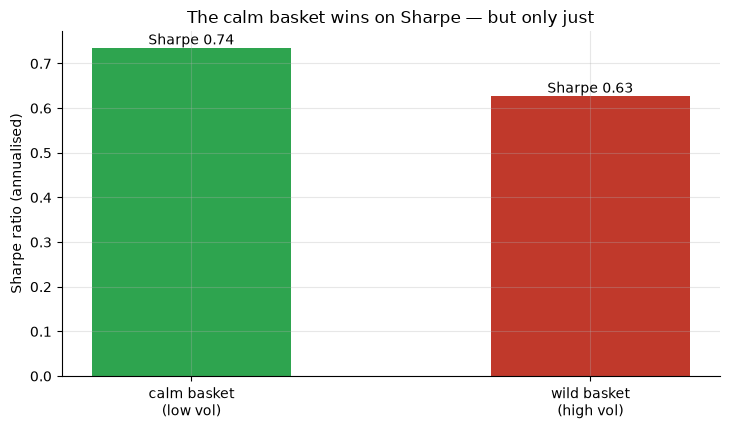

low-vol Sharpe 0.74  vs  high-vol Sharpe 0.63 (a +0.11 gap)


In [2]:
if HAVE_REAL:
    legs = st.leg_returns(PRICES)
    lo, hi = st.summary(legs['low']), st.summary(legs['high'])
    low_sr, high_sr = lo['sharpe'], hi['sharpe']
else:
    low_sr, high_sr = R['low_sharpe'], R['high_sharpe']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['calm basket\n(low vol)', 'wild basket\n(high vol)'], [low_sr, high_sr],
       color=[GREEN, RED], width=.5)
for i,v in enumerate([low_sr, high_sr]): ax.annotate(f'Sharpe {v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe ratio (annualised)')
ax.set_title('The calm basket wins on Sharpe — but only just')
plt.tight_layout(); plt.show()
print(f'low-vol Sharpe {low_sr:.2f}  vs  high-vol Sharpe {high_sr:.2f} '
      f'(a {low_sr-high_sr:+.2f} gap)')

So the anomaly is *faintly* there: the calm basket's Sharpe (**0.74**) edges the wild one's (**0.63**). A **+0.11** gap. That's the whole prize — and it's small. The question is whether you can actually *capture* it by levering the calm leg up to match the wild one.

**So let's build that trade — the risk-matched low-minus-high spread — and see what it makes.**

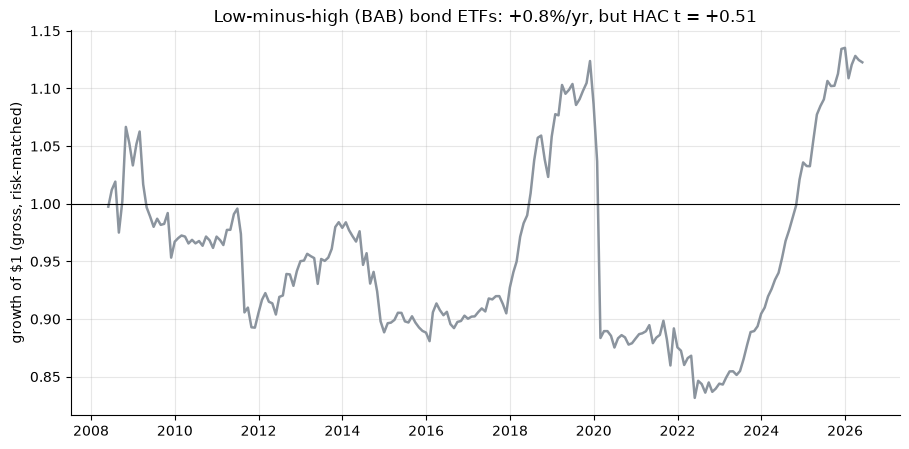

BAB spread +0.84%/yr, HAC t = +0.51 (the bar is 2.0)


In [3]:
if HAVE_REAL:
    s = st.summary(BK['bab_gross'])
    eq = (1 + BK['bab_gross']).cumprod()
    mean_pct, t = s['mean']*100, s['tstat']
else:
    mean_pct, t = R['mean_pct'], R['hac_t']
    idx = pd.date_range('2008-06-30', periods=R['n'], freq='ME')
    rng = np.random.default_rng(796)
    eq = pd.Series((1+rng.normal(R['mean_pct']/100/12, R['vol_pct']/100/np.sqrt(12), R['n'])).cumprod(), index=idx)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(eq.index, eq.values, color=GREY, lw=1.8)
ax.axhline(1.0, c='k', lw=.8)
ax.set_ylabel('growth of $1 (gross, risk-matched)')
ax.set_title(f'Low-minus-high (BAB) bond ETFs: {mean_pct:+.1f}%/yr, but HAC t = {t:+.2f}')
plt.tight_layout(); plt.show()
print(f'BAB spread {mean_pct:+.2f}%/yr, HAC t = {t:+.2f} (the bar is 2.0)')

A flat-to-drifting line that could easily be a straight zero. The spread makes **+0.8%/yr** with an honest **HAC *t* = +0.51** — the desk bar is 2.0, and this is nowhere near. Worse, it drops **-26%** at its trough and has a single **-14.8%** month. It *wins* often (**59%** of months are positive) but the rare disasters — when levered safe assets and shorted risky ones both go the wrong way at once — wipe out the drip of small gains.

**Now the check that really sinks it: is it even the *volatility* ranking that's working, or just the leverage?**

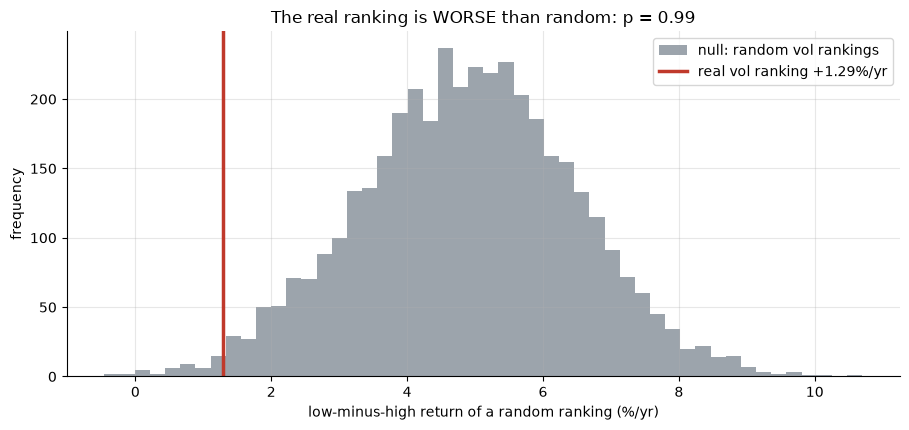

real vol ranking +1.29%/yr vs random rankings averaging +4.87%/yr; p = 0.989 (a random ranking beats the real one almost always)


In [4]:
obs, pm, psd, p = R['placebo_real_pct'], R['placebo_mean_pct'], R['placebo_sd_pct'], R['placebo_p']
rng = np.random.default_rng(796)
draws = rng.normal(pm, psd, 4000)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random vol rankings')
ax.axvline(obs, c=RED, lw=2.5, label=f'real vol ranking {obs:+.2f}%/yr')
ax.set_xlabel('low-minus-high return of a random ranking (%/yr)')
ax.set_ylabel('frequency')
ax.set_title(f'The real ranking is WORSE than random: p = {p:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real vol ranking {obs:+.2f}%/yr vs random rankings averaging {pm:+.2f}%/yr; '
      f'p = {p:.3f} (a random ranking beats the real one almost always)')

This is the tell. When we randomly relabel which ETF is 'calm' and which is 'wild', the *random* rankings earn **more** (+4.9%/yr) than the real volatility ranking (+1.3%/yr): **p = 0.99**. The spread's returns come from *levering the low-vol leg*, not from correctly identifying the safe assets — and it turns out the genuinely calm names (short-duration Treasuries) are among the *worst* things to lever. Ranking by real volatility adds nothing.

**Finally: can any version of it be traded?**

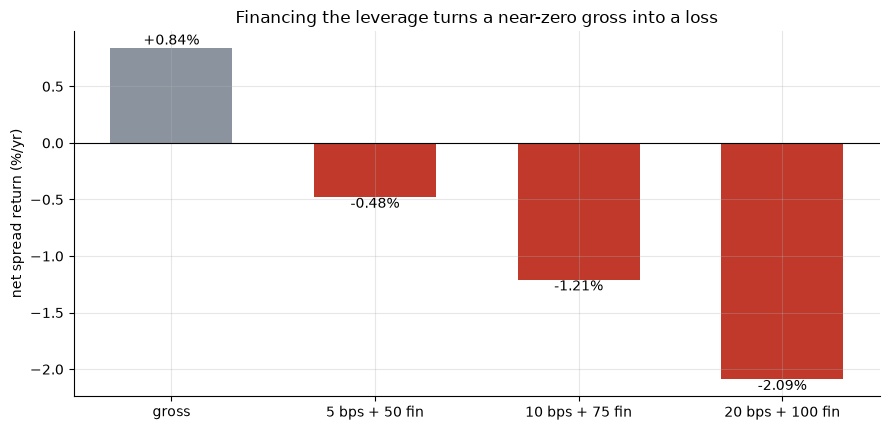

{'5 bps + 50 fin': -0.48, '10 bps + 75 fin': -1.21, '20 bps + 100 fin': -2.09}


In [5]:
labels = ['gross'] + list(R['costs'])
vals = [R['mean_pct']] + [R['costs'][k][0] for k in R['costs']]
cols = [GREY] + [RED]*len(R['costs'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net spread return (%/yr)')
ax.set_title('Financing the leverage turns a near-zero gross into a loss')
plt.tight_layout(); plt.show()
print({l: R['costs'][l][0] for l in R['costs']})

There was never a gross edge to protect, and levering the safe leg ~2.6x means you pay financing on all that borrowed exposure. Net of realistic costs the spread is **negative at every level**. Nothing to trade.

## 5 · The verdict

- **Signal — None.** The risk-matched low-minus-high spread earns +0.8%/yr at HAC *t* = +0.51 — statistically invisible — and a **random** volatility ranking beats it (placebo p = 0.99). The calm basket's Sharpe edge (0.74 vs 0.63) is real but tiny and doesn't survive being turned into a trade.
- **Tradability — Mirage.** The spread levers the safe leg heavily, so financing plus trading costs push the near-zero gross to a **negative** net everywhere.
- **"Is it the real volatility ranking that pays?" — Not supported.** A random ranking earns more; the returns are a leverage artifact, not a low-risk signal. Exactly what you'd expect when a dozen ETFs are too coarse to reproduce the single-name low-risk cross-section the anomaly actually lives in.

## 6 · Going further 🚪

- **Why it fails as ETFs.** Betting-against-beta needs a rich cross-section of names with genuinely different risk *and* mispricing. A dozen broad bond ETFs collapses each sleeve into one number, and the calmest names (short-duration Treasuries) barely move — so levering them up harvests almost nothing while carrying financing and tail risk.
- **What might work instead:** the single-name corporate-bond cross-section (TRACE) or a duration-and-credit-neutral construction where the *within-sleeve* risk dispersion survives.
- **Sibling studies:** [238-betting-against-beta](../../238-betting-against-beta/) (BAB in **equities**, where it's real), [330-low-volatility-anomaly](../../330-low-volatility-anomaly/) (the low-vol anomaly in **stocks**), and [795-corporate-bond-momentum](../../795-corporate-bond-momentum/) (the *momentum* leg on this same bond-ETF tape) — see [docs/references.md](docs/references.md) for the exact dedup.

*Think bond-ETF betting-against-beta can be made to pay? Show a certifiable HAC *t* ≥ 2 that beats a random-ranking placebo, net of the financing on the leverage — then we'll talk.*